In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("2-multiplegradesdataset.csv")

In [3]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Study Hours         50 non-null     float64
 1   Sleep Hours         50 non-null     float64
 2   Attendance Rate     50 non-null     float64
 3   Social Media Hours  50 non-null     float64
 4   Exam Score          50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


In [5]:
df.isnull().sum()

Study Hours           0
Sleep Hours           0
Attendance Rate       0
Social Media Hours    0
Exam Score            0
dtype: int64

In [7]:
df.corr()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
Study Hours,1.000000,0.114015,-0.112860,0.115023,0.804266
Sleep Hours,0.114015,1.000000,-0.222024,-0.177166,0.227694
Attendance Rate,-0.112860,-0.222024,1.000000,0.068272,0.123791
Social Media Hours,0.115023,-0.177166,0.068272,1.000000,-0.248743
Exam Score,0.804266,0.227694,0.123791,-0.248743,1.000000


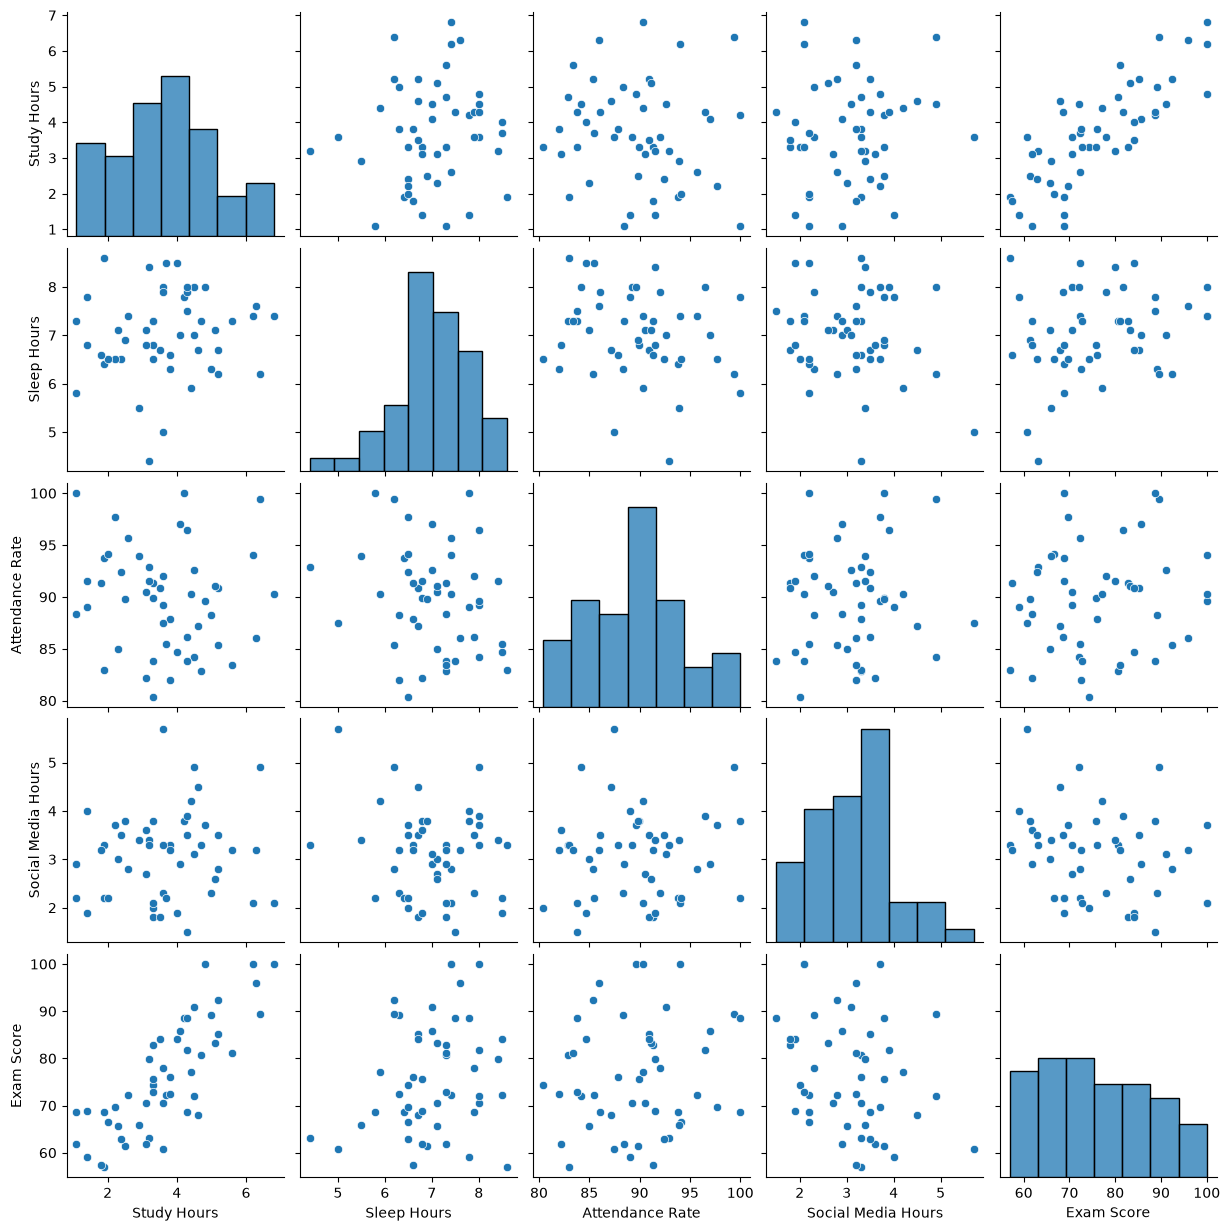

In [9]:
sns.pairplot(df)

In [10]:
df.corr()["Exam Score"]

Study Hours           0.804266
Sleep Hours           0.227694
Attendance Rate       0.123791
Social Media Hours   -0.248743
Exam Score            1.000000
Name: Exam Score, dtype: float64

In [11]:
df.columns

Index(['Study Hours', 'Sleep Hours', 'Attendance Rate', 'Social Media Hours',
       'Exam Score'],
      dtype='str')

In [13]:
X = df[['Study Hours', 'Sleep Hours', 'Attendance Rate', 'Social Media Hours']]
y = df['Exam Score']

#X = df.iloc[:,:-1]
#y = df.iloc[:, -1]

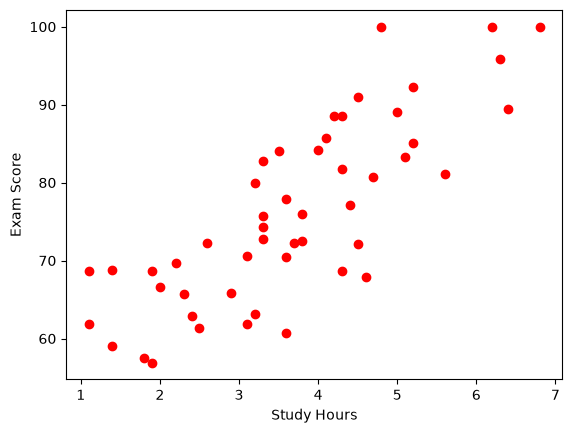

In [15]:
plt.scatter(df["Study Hours"], df["Exam Score"], color='red')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

<Axes: xlabel='Study Hours', ylabel='Exam Score'>

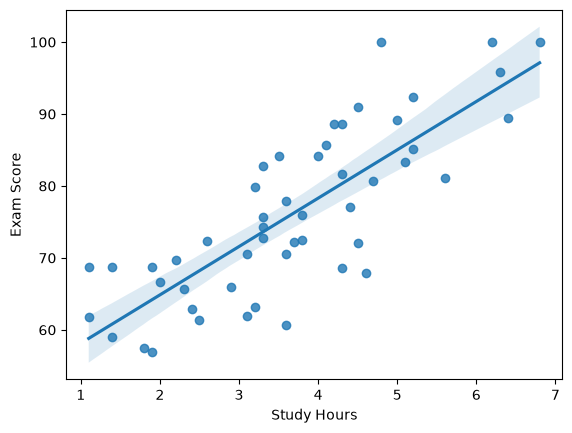

In [17]:
sns.regplot(x = df["Study Hours"], y =df["Exam Score"])

In [18]:
X

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3
5,3.6,7.9,92.0,2.3
6,6.4,6.2,99.4,4.9
7,5.2,6.7,90.9,3.5
8,3.3,7.3,91.3,1.8
9,4.8,8.0,89.6,3.7


In [19]:
y

0      80.7
1      76.0
2      89.1
3      95.9
4      70.5
5      77.9
6      89.5
7      85.1
8      82.8
9     100.0
10     74.3
11     75.7
12     77.1
13     68.7
14     59.0
15     79.9
16     61.4
17     72.1
18     72.3
19     68.7
20    100.0
21     72.2
22     85.7
23     56.9
24     63.2
25     88.6
26     65.7
27     67.9
28     70.6
29     60.7
30     61.9
31    100.0
32     84.2
33     62.9
34     92.3
35     69.7
36     68.6
37     61.8
38     66.6
39     88.6
40     83.3
41     81.7
42     72.5
43     84.1
44     57.5
45     65.9
46     72.8
47     81.1
48     91.0
49     68.8
Name: Exam Score, dtype: float64

In [20]:
#train test split

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [24]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train) #çalışma soruları
X_test = scaler.transform(X_test) #sınav soruları

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
regression = LinearRegression()

In [30]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[10.12, 1.23, 2.47,-3.6 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,76.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[7.34,6.42,5.96,5.42]"


In [31]:
regression.coef_

array([10.11954143,  1.22980868,  2.46755688, -3.60019752])

In [32]:
regression.intercept_

np.float64(76.2025)

In [34]:
#prediction
y_pred = regression.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [36]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("mse = ",mse)
print("mae = ",mae)
print("r2 = ",r2)

mse =  14.744713821185451
mae =  3.17006740662626
r2 =  0.8702442761946606


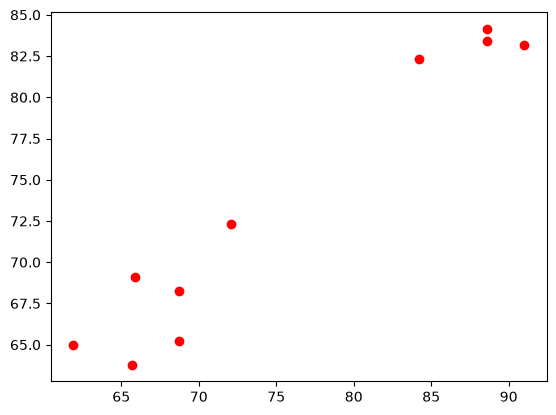

In [37]:
plt.scatter(y_test, y_pred, color='red')

In [41]:
students = [
    [6,8,95,5],
    [3,6,85,4],
    [4,7,80,3]
]

In [42]:
regression.predict(scaler.transform(students))

C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([88.66185082, 63.00595085, 72.90528407])